In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df=pd.read_csv("../cleaning/cleaned_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9877 entries, 0 to 9876
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                9864 non-null   float64
 1   price_per_sqft       9864 non-null   float64
 2   super_built_up_area  2468 non-null   float64
 3   carpet_area          7930 non-null   float64
 4   builtup_area         3274 non-null   float64
 5   facing               7586 non-null   object 
 6   ownership            9835 non-null   object 
 7   bedrooms             9792 non-null   float64
 8   bathrooms            9791 non-null   float64
 9   balcony              9793 non-null   float64
 10  floor                9759 non-null   float64
 11  furnish_type         8959 non-null   object 
 12  prop_type            9833 non-null   object 
 13  city                 9877 non-null   object 
 14  luxury_score         9877 non-null   int64  
 15  Others               9877 non-null   i

### Outlier Detection & treatment

#### Price

##### Using IQR method

<Axes: xlabel='price'>

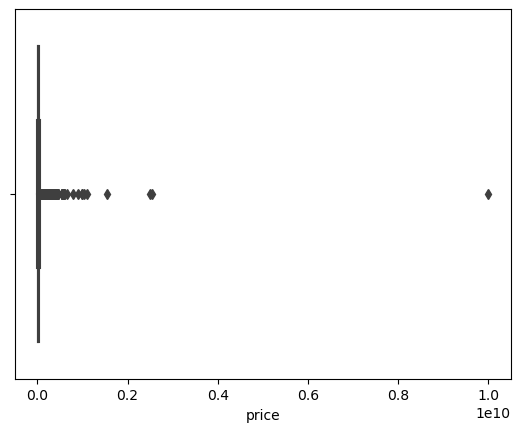

In [4]:
sns.boxplot(data=df,x='price')

In [5]:
Q3 = df['price'].quantile(0.75)
Q1 = df['price'].quantile(0.25)
iqr=Q3-Q1

In [6]:
# df[(df['price'] <= Q1 - 3.5*iqr) | (df['price'] >= Q3 + 3.5*iqr) ].to_csv('price.csv')
#6203, 6008, 6447, 5727, 5953, 6344, 6103, 6203, 8399, 5655, 5871, 5415, 5994, 2155, 8714, 4675, 5832, 5982
# 5739 Extreme outliers

df.drop(index=[6203, 6008, 6447, 5727, 5953, 6344, 6103, 6203, 8399, 5655, 5871, 5415, 5994, 2155, 8714, 4675, 5832, 5982, 5739],inplace=True)

<Axes: >

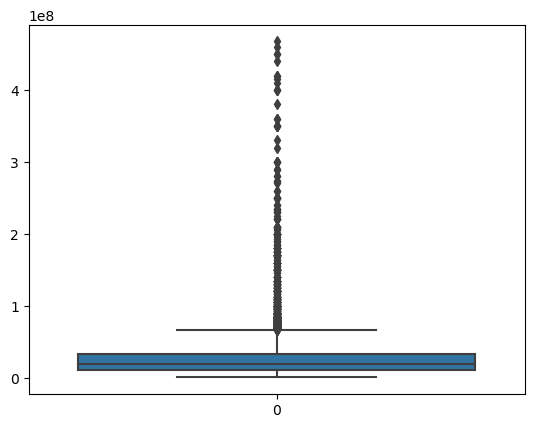

In [7]:
filter_df = df[df['price']< 50.e+7]
sns.boxplot(filter_df['price'])

In [8]:
filtered_df = df[(df['price'] >= Q1 - 3.5*iqr) & (df['price'] <= Q3 + 3.5*iqr)]
print(filtered_df.shape)
print(df.shape)

(9592, 22)
(9859, 22)


In [9]:
filtered_df2 = df[(df['price']>=Q1-(2.5*iqr)) & (df['price']<=Q3+(2.5*iqr))]
print(filtered_df2.shape)

(9450, 22)


In [10]:
filtered_df3 = df[(df['price']>=Q1-(1.5*iqr)) & (df['price']<=Q3+(1.5*iqr))]
print(filtered_df3.shape)

(9130, 22)


<Axes: xlabel='price'>

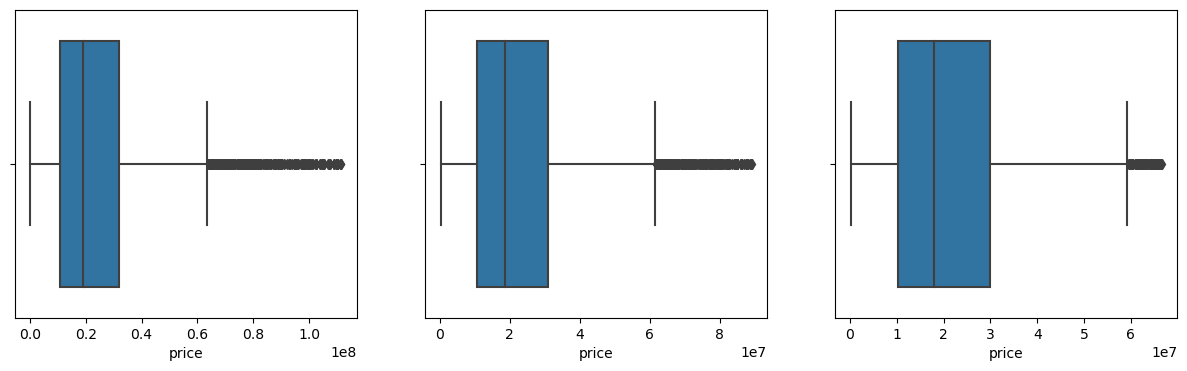

In [11]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
sns.boxplot(data=filtered_df, x=filtered_df['price'], ax = axes[0])
sns.boxplot(data=filtered_df2, x=filtered_df2['price'], ax = axes[1])
sns.boxplot(data=filtered_df3, x=filtered_df3['price'], ax = axes[2])

Text(0.5, 1.0, 'IQR=1.5')

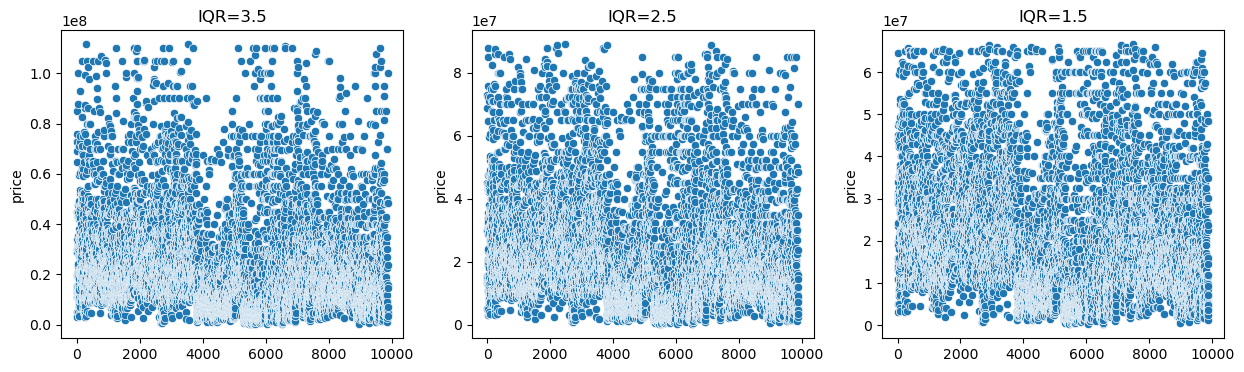

In [12]:
fig,axes = plt.subplots(1,3,figsize=(15,4))
sns.scatterplot(x=filtered_df.index, y=filtered_df['price'], ax=axes[0])
axes[0].set_title("IQR=3.5")

sns.scatterplot(x=filtered_df2.index, y=filtered_df2['price'], ax=axes[1])
axes[1].set_title("IQR=2.5")

sns.scatterplot(x=filtered_df3.index, y=filtered_df3['price'], ax=axes[2])
axes[2].set_title("IQR=1.5")

##### Using Capping method

In [13]:
q1 = df['price'].quantile(0.01)
q99 = df['price'].quantile(0.98)
capped_df=df.copy()

In [14]:
df['price'].describe()

count    9.846000e+03
mean     3.111499e+07
std      1.169879e+08
min      2.000000e+05
25%      1.100000e+07
50%      1.950000e+07
75%      3.330000e+07
max      1.000000e+10
Name: price, dtype: float64

In [15]:
capped_df=capped_df[(capped_df['price'].isna()) | (capped_df['price']>q1) & (capped_df['price']<q99) ]
print(capped_df.shape)

(9555, 22)


<Axes: ylabel='price'>

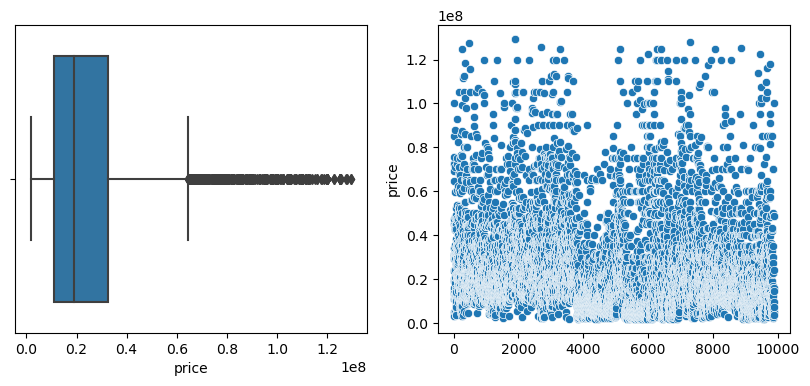

In [16]:
fig, axes = plt.subplots(1,2,figsize=(10,4))
sns.boxplot(x=capped_df['price'],ax = axes[0])
sns.scatterplot(x=capped_df.index,y=capped_df['price'],ax= axes[1])

#### Area

<Axes: xlabel='super_built_up_area'>

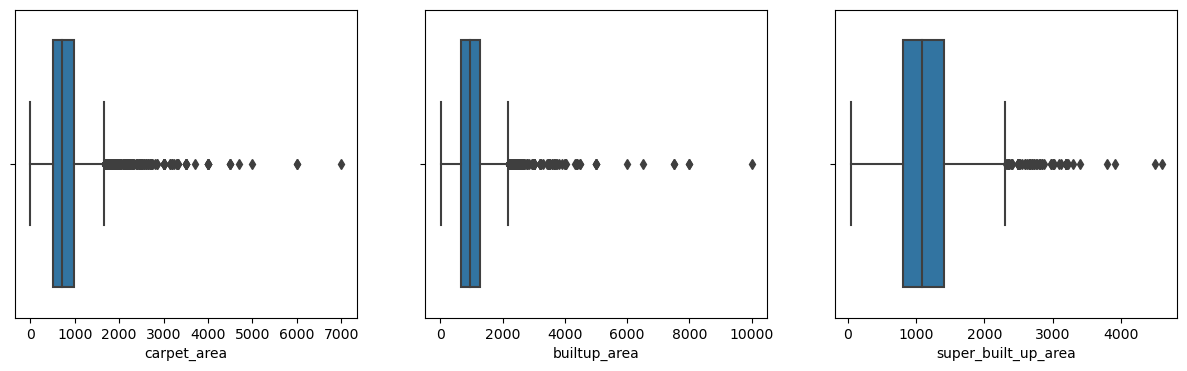

In [17]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
sns.boxplot(data=filtered_df, x=filtered_df['carpet_area'], ax = axes[0])
sns.boxplot(data=filtered_df, x=filtered_df['builtup_area'], ax = axes[1])
sns.boxplot(data=filtered_df, x=filtered_df['super_built_up_area'], ax = axes[2])

In [18]:
q1=filtered_df['carpet_area'].quantile(0.25)
q3=filtered_df['carpet_area'].quantile(0.75)
iqr=q3-q1
print(filtered_df.shape)

(9592, 22)


In [19]:
filtered_df.loc[(filtered_df['carpet_area']< q1 - 3*iqr) | (filtered_df['carpet_area']> q3 + 3*iqr) ].to_csv('carpetarea.csv')

<Axes: xlabel='super_built_up_area'>

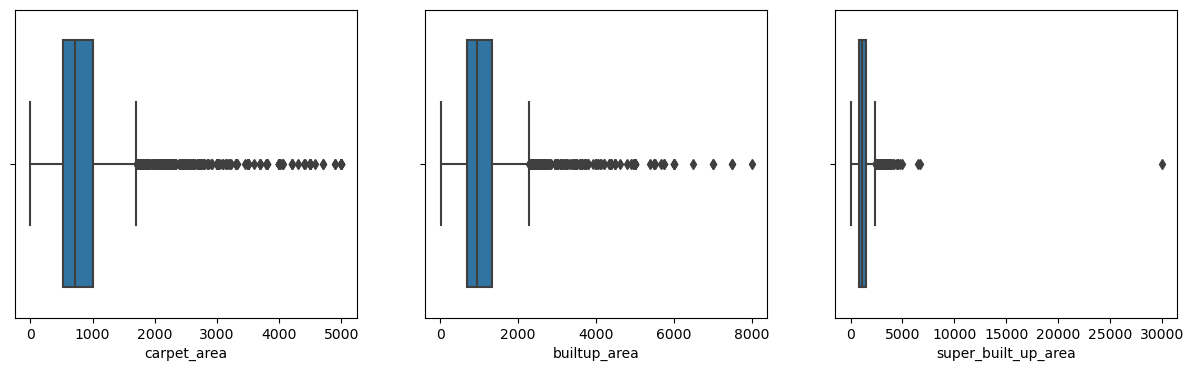

In [20]:
filter_df = filter_df[(filter_df['carpet_area']<=5000) | (filter_df['carpet_area'].isna())]
# filter_df = filter_df[filter_df['builtup_area']<=6000 | (filter_df['builtup_area'].isna())]
# filter_df = filter_df[filter_df['super_built_up_area']<=5000 | (filter_df['super_built_up_area'].isna())]

fig, axes = plt.subplots(1,3,figsize=(15,4))
sns.boxplot(data=filter_df, x=filter_df['carpet_area'], ax = axes[0])
sns.boxplot(data=filter_df, x=filter_df['builtup_area'], ax = axes[1])
sns.boxplot(data=filter_df, x=filter_df['super_built_up_area'], ax = axes[2])

In [21]:
filtered_df = filtered_df.loc[(filtered_df['carpet_area'].isna()) | (filtered_df['carpet_area']> q1 - 3*iqr) & (filtered_df['carpet_area']< q3 + 3*iqr) ]
print(filtered_df.shape)

(9504, 22)


In [22]:
q99=filtered_df['builtup_area'].quantile(0.989)
filtered_df = filtered_df.loc[(filtered_df['builtup_area'].isna()) | (filtered_df['builtup_area']<2800) ]
print(filtered_df.shape)

(9473, 22)


In [23]:
q99=filtered_df['super_built_up_area'].quantile(0.991)
filtered_df = filtered_df.loc[(filtered_df['super_built_up_area'].isna()) | (filtered_df['super_built_up_area']<3500) ]
print(filtered_df.shape)

(9471, 22)


<Axes: xlabel='super_built_up_area'>

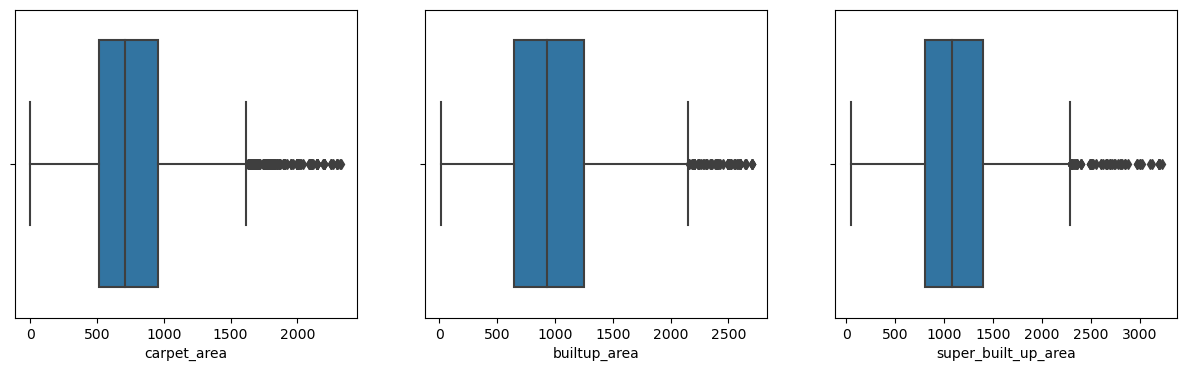

In [24]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
sns.boxplot(data=filtered_df, x=filtered_df['carpet_area'], ax = axes[0])
sns.boxplot(data=filtered_df, x=filtered_df['builtup_area'], ax = axes[1])
sns.boxplot(data=filtered_df, x=filtered_df['super_built_up_area'], ax = axes[2])

#### luxury score

<Axes: >

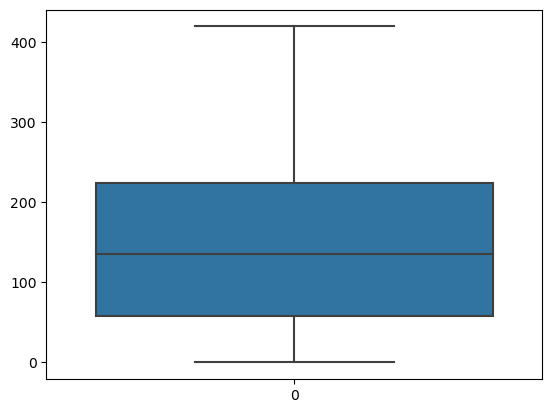

In [25]:
sns.boxplot(filtered_df['luxury_score'])

#### price per sqft

<Axes: >

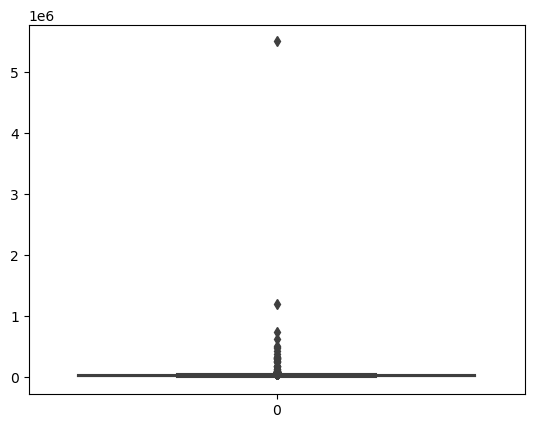

In [26]:
sns.boxplot(filtered_df['price_per_sqft'])

In [27]:
q99=filtered_df['price_per_sqft'].quantile(0.995)
filtered_df[filtered_df['price_per_sqft']>q99].to_csv('ppsqft.csv')
filtered_df = filtered_df[(filtered_df['price_per_sqft'].isna()) | (filtered_df['price_per_sqft']<q99)]
print(filtered_df.shape)

(9423, 22)


<Axes: >

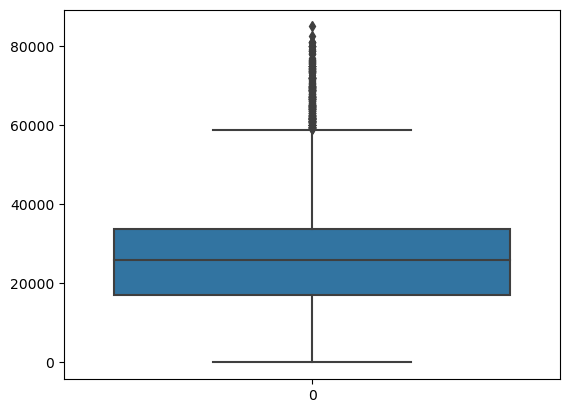

In [28]:
filter_df = filter_df[(filter_df['price_per_sqft']<85000) | (filter_df['price_per_sqft'].isna())]
sns.boxplot(filter_df['price_per_sqft'])

<Axes: >

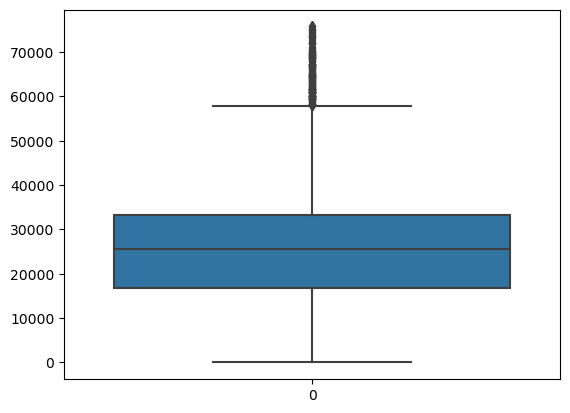

In [29]:
sns.boxplot(filtered_df['price_per_sqft'])

#### bedroom , bathroom & balcony

<Axes: xlabel='balcony'>

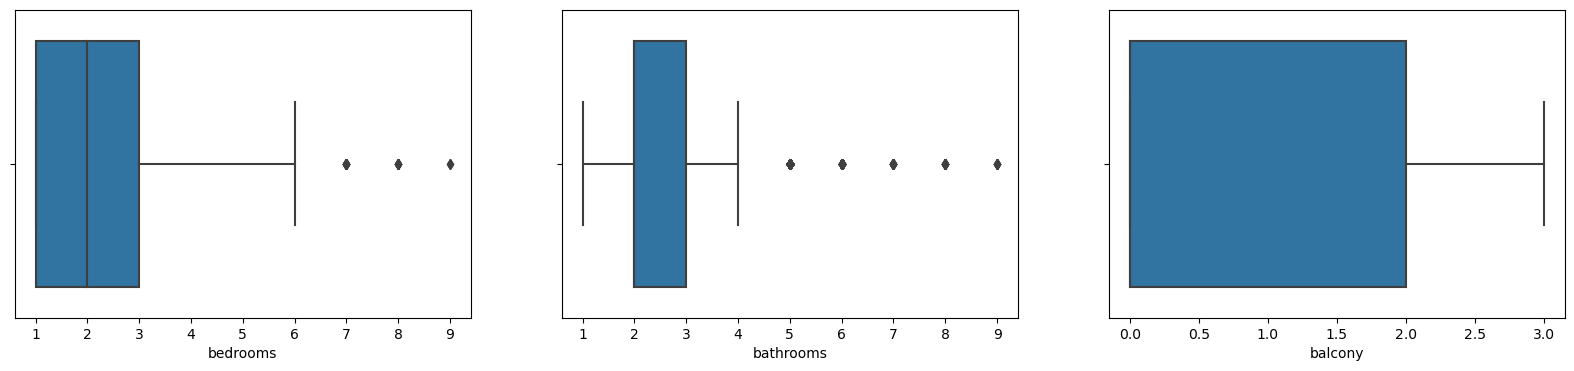

In [30]:
fig, axes = plt.subplots(1,3,figsize=(20,4))
sns.boxplot(x=df['bedrooms'],ax=axes[0])
sns.boxplot(x=df['bathrooms'],ax=axes[1])
sns.boxplot(x=df['balcony'],ax=axes[2])

In [31]:
filter_df.to_csv('cleaned_data_go.csv',index=False)
filtered_df.to_csv('cleaned_data_ro.csv', index=False)